# Chapter 04 — Ensembles and Restarts: an NPT sketch in mdlite, LAMMPS's fix npt, and restart continuation

*lammps-skill 0.1.11. Generated by `build/assemble.py` — do not edit this notebook; edit `build/chapter04_ensembles_restarts.py` and re-assemble.*

**Needs a LAMMPS installation:** yes

## Contents

1. [](#)
2. [](#)
3. [](#)
4. [](#)
5. [](#)

In [1]:
# Setup -- run me first.
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the product root, when run from chapters/

import lammpskill
from lammpskill.install import detect_all

print("lammps-skill", lammpskill.__version__, "| python", sys.version.split()[0])
INSTALLATIONS = detect_all()
if INSTALLATIONS:
    for i in INSTALLATIONS:
        print("  %-11s %-24s %s" % (i.route, i.version, i.executable or "(library only)"))
else:
    print("  no LAMMPS installation detected -- chapters marked 'no LAMMPS needed' still run;")
    print("  the others load their recorded results instead (record-or-run).")

lammps-skill 0.1.11 | python 3.12.14


  wsl-apt     10 Dec 2025              /usr/bin/lmp
  wsl-source  22 Jul 2025 - Update 6   /home/fabio/.local/bin/lmp_core


## Two ways state outlives one `run`

An NPT ensemble lets the box respond to a target pressure instead of holding it fixed; a restart
lets a simulation stop and pick up again as if it never had. Both are about state that survives
past the boundary of a single `run` command -- one across an ensemble, one across a process.

## The mdlite NPT sketch, and its limits

`mdlite.npt.BerendsenBarostat` rescales the box toward a target pressure by weak coupling
(Berendsen et al. 1984) -- the same trade `mdlite.thermostats.Berendsen` makes for temperature.
**State plainly: this is not a fluctuating-cell method.** There is no Parrinello-Rahman or
Martyna-Tuckerman-Klein cell mass, and it does not sample the isothermal-isobaric ensemble
correctly -- it relaxes the box toward the target and holds it there. That is enough to show what
NPT is *for* (a system finds its own equilibrium volume at a given pressure, rather than being told
one), not a claim that this is a research-grade barostat.

In [2]:
import numpy as np

from mdlite.box import Box
from mdlite.integrate import State
from mdlite.neighbors import VerletList
from mdlite.npt import BerendsenBarostat, velocity_verlet_npt
from mdlite.pair import LennardJones
from mdlite.thermostats import Berendsen


def fcc(n, rho):
    a = (4.0 / rho) ** (1.0 / 3.0)
    base = np.array([[0, 0, 0], [0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5]]) * a
    cells = np.array([[i, j, k] for i in range(n) for j in range(n) for k in range(n)]) * a
    return (cells[:, None, :] + base[None, :, :]).reshape(-1, 3), Box([n * a] * 3)


# start denser than the target pressure equilibrates to -- the box should expand.
pos, box = fcc(3, 1.1)
rng = np.random.default_rng(3)
vel = rng.normal(0, np.sqrt(2.0), pos.shape)
vel -= vel.mean(0)
st = State(pos, vel, 1.0, box)
vl = VerletList(box, 2.5)
rec_npt = velocity_verlet_npt(st, [LennardJones()], dt=0.005, nsteps=1500, nlist=vl, thermostat=Berendsen(2.0, 0.5),
                               barostat=BerendsenBarostat(P0=1.0, tau=2.0), every=15)
V = np.array([r["V"] for r in rec_npt])
P = np.array([r["P"] for r in rec_npt])
print("volume: start=%.2f  end=%.2f  (expect expansion toward the lower target pressure)" % (V[0], V[-1]))
print("pressure: start=%.3f  end (last 10 avg)=%.3f  (target 1.0)" % (P[0], P[-10:].mean()))
assert V[-1] > V[0]

volume: start=98.18  end=238.27  (expect expansion toward the lower target pressure)
pressure: start=4.258  end (last 10 avg)=0.953  (target 1.0)


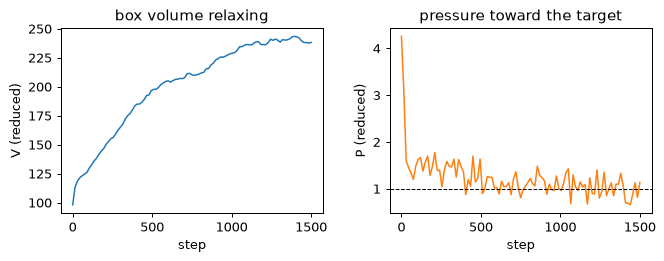

In [3]:
import matplotlib.pyplot as plt

step = [r["step"] for r in rec_npt]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3), dpi=90)
ax1.plot(step, V, lw=1.2)
ax1.set_xlabel("step"); ax1.set_ylabel("V (reduced)"); ax1.set_title("box volume relaxing")
ax2.plot(step, P, lw=1.2, color="tab:orange")
ax2.axhline(1.0, color="k", ls="--", lw=0.8)
ax2.set_xlabel("step"); ax2.set_ylabel("P (reduced)"); ax2.set_title("pressure toward the target")
fig.tight_layout()
plt.show()

## The same idea in LAMMPS: `fix npt`

LAMMPS's `fix npt` couples a Nosé–Hoover chain on *both* temperature and pressure -- a real
fluctuating-cell method, not a sketch. Record-or-run gives a live number when LAMMPS is present.

In [4]:
import tempfile

from lammpskill.run import run, run_or_load
from lammpskill.script import Spec, Stage

npt_spec = Spec(
    units="lj", atom_style="atomic", lattice="fcc 1.1", region="box block 0 5 0 5 0 5",
    create_box=1, create_atoms="1 box", masses={1: 1.0}, pair_style="lj/cut 2.5", pair_coeffs=["1 1 1.0 1.0 2.5"],
    neighbor="0.3 bin", neigh_modify="every 20 delay 0 check no",
    velocity=["all create 2.0 4242 loop geom"], timestep=0.005,
    fixes=["1 all npt temp 2.0 2.0 0.5 iso 1.0 1.0 2.0"], thermo=50, thermo_style="custom step temp press vol",
    stages=[Stage("run", "1500")], comment="LJ, fix npt from a compressed start -- same target pressure as the mdlite sketch above",
)


def compute_npt():
    workdir = tempfile.mkdtemp(prefix="ch04_npt_")
    result = run(npt_spec, workdir, time_limit=300)
    if not result.ok:
        raise RuntimeError("fix npt run failed (rc=%s): %s" % (result.returncode, "; ".join(result.errors) or result.stderr))
    t = result.thermo
    vol, press = t.get("Volume") if "Volume" in t.columns else t.get("Vol"), t.get("Press")
    n_tail = max(1, len(vol) // 4)
    return {"natoms": t.natoms, "route": result.installation.route if result.installation else None,
            "V_start": float(vol[0]), "V_end_mean": float(vol[-n_tail:].mean()),
            "P_end_mean": float(press[-n_tail:].mean())}


npt_rec = run_or_load("lj_npt_ch04", compute_npt, records_dir="../data/records")
print("source:", npt_rec["source"])
if npt_rec["source"] != "skip":
    print("route:", npt_rec.get("route"))
    print("LAMMPS fix npt: V start=%.2f -> end (last quarter avg)=%.2f, P end (last quarter avg)=%.3f (target 1.0)"
          % (npt_rec["V_start"], npt_rec["V_end_mean"], npt_rec["P_end_mean"]))
else:
    print("no LAMMPS available and no record yet:", npt_rec.get("reason"))

source: record
route: wsl-apt
LAMMPS fix npt: V start=454.55 -> end (last quarter avg)=1066.64, P end (last quarter avg)=1.197 (target 1.0)


## Restart continuation

A `Spec` with `read_restart` in `pre` runs before the auto-generated `units` line -- which is
exactly the problem: `read_restart` defines the box, and LAMMPS refuses a `units` command once the
box exists (`ERROR: Units command after simulation box is defined`, hit while writing this
chapter). `Spec.units` accepts `None` for exactly this case -- it omits the line entirely, since the
restart file already carries the units. Nothing else the restart carries (box, atoms, velocities)
needs to be declared again; only the settings a restart does not always carry (pair style and
coefficients here) are repeated.

In [5]:
def compute_restart():
    workdir = tempfile.mkdtemp(prefix="ch04_restart_")
    stage_a = Spec(
        units="lj", atom_style="atomic", lattice="fcc 0.8442", region="box block 0 5 0 5 0 5",
        create_box=1, create_atoms="1 box", masses={1: 1.0}, pair_style="lj/cut 2.5", pair_coeffs=["1 1 1.0 1.0 2.5"],
        neighbor="0.3 bin", neigh_modify="every 20 delay 0 check no",
        velocity=["all create 2.0 12345 loop geom"], timestep=0.005, fixes=["1 all nve"],
        thermo=50, thermo_style="custom step temp pe etotal", stages=[Stage("run", "300")],
        post=["write_restart stage_a.restart"], comment="stage A: 300 steps, then checkpoint",
    )
    res_a = run(stage_a, workdir, time_limit=300)
    if not res_a.ok:
        raise RuntimeError("restart stage A failed: %s" % (res_a.errors or res_a.stderr))

    stage_b = Spec(
        units=None, pre=["read_restart stage_a.restart"],
        pair_style="lj/cut 2.5", pair_coeffs=["1 1 1.0 1.0 2.5"],
        neighbor="0.3 bin", neigh_modify="every 20 delay 0 check no",
        timestep=0.005, fixes=["1 all nve"], thermo=50, thermo_style="custom step temp pe etotal",
        stages=[Stage("run", "300")], comment="stage B: continue from the restart for 300 more steps",
    )
    res_b = run(stage_b, workdir, time_limit=300, input_name="in.b.lammps", log_name="log.b.lammps")
    if not res_b.ok:
        raise RuntimeError("restart stage B failed: %s" % (res_b.errors or res_b.stderr))

    return {"route": res_a.installation.route if res_a.installation else None,
            "step_a_final": res_a.thermo.last.get("Step"), "step_b_final": res_b.thermo.last.get("Step"),
            "temp_a_final": res_a.thermo.last.get("Temp"), "temp_b_final": res_b.thermo.last.get("Temp")}


restart_rec = run_or_load("lj_restart_ch04", compute_restart, records_dir="../data/records")
print("source:", restart_rec["source"])
if restart_rec["source"] != "skip":
    print("route:", restart_rec.get("route"))
    print("stage A ended at step %s (T=%.3f); stage B, continued from the restart, ended at step %s (T=%.3f)"
          % (restart_rec["step_a_final"], restart_rec["temp_a_final"], restart_rec["step_b_final"], restart_rec["temp_b_final"]))
    assert restart_rec["step_b_final"] == restart_rec["step_a_final"] + 300
else:
    print("no LAMMPS available and no record yet:", restart_rec.get("reason"))

source: record
route: wsl-apt
stage A ended at step 300.0 (T=1.036); stage B, continued from the restart, ended at step 600.0 (T=1.019)


## Reading it

- The mdlite sketch and `fix npt` are answering the same question -- "what volume does this system
  settle at, at this pressure" -- with methods of very different rigor. Comparing them is a check
  on the *sketch's direction*, not a claim they agree quantitatively.
- A restart file is not a snapshot a script can casually reconstruct: `stage_b` above declares only
  what the restart does not carry (pair style, coefficients), and the checker (chapter 01) would
  flag it as `read_data`-shaped if it tried to re-declare the box.
- Both mechanisms exist for the same underlying reason as `run_or_load` itself: a long computation
  should not have to happen exactly once, in exactly one process, to be usable.

In [6]:
# Tally -- what this chapter claimed, checked.
checks = []
checks.append(('the mdlite NPT sketch expanded a compressed system toward its lower target pressure', bool(V[-1] > V[0])))
checks.append(('run_or_load (fix npt) returned one of its three documented outcomes', bool(npt_rec['source'] in ('run', 'record', 'skip'))))
checks.append(('run_or_load (restart) returned one of its three documented outcomes', bool(restart_rec['source'] in ('run', 'record', 'skip'))))

for label, ok in checks:
    print(('PASS' if ok else 'FAIL'), label)
assert all(ok for _, ok in checks), 'chapter 04: a claim above is not true'
print('chapter 04: %d claim(s) checked' % len(checks))

PASS the mdlite NPT sketch expanded a compressed system toward its lower target pressure
PASS run_or_load (fix npt) returned one of its three documented outcomes
PASS run_or_load (restart) returned one of its three documented outcomes
chapter 04: 3 claim(s) checked
